# ASL Alphabet Letter Classifier

Train a CNN to classify 29 ASL hand signs (A-Z, del, nothing, space) using PyTorch.

## 1. Imports

Import PyTorch, torchvision, matplotlib, and other utilities needed for data loading, model training, and evaluation.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import torch_directml
from tqdm import tqdm

device = torch_directml.device()
print(f"Using device: {device}")

Using device: privateuseone:0


## 2. Dataset paths & transforms

Point to the training and test directories. Images are resized to 128x128, converted to tensors, and normalized.

In [5]:
TRAIN_DIR = Path("datasets/aslAlphabet/asl_alphabet_train/asl_alphabet_train")
TEST_DIR = Path("datasets/aslAlphabet/asl_alphabet_test/asl_alphabet_test")

IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 0.001

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

## 3. Load dataset & split into train/val

Use `ImageFolder` from torchvision to load the data. Split 80% for training and 20% for validation.

In [6]:
full_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transform)

val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

test_dataset = datasets.ImageFolder(root=str(TEST_DIR), transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Train: {train_size}  Val: {val_size}  Test: {len(test_dataset)}")

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Train: 69600  Val: 17400  Test: 28


## 4. Visualise a batch of training images

Display a grid of sample images with their labels to verify the data looks correct.

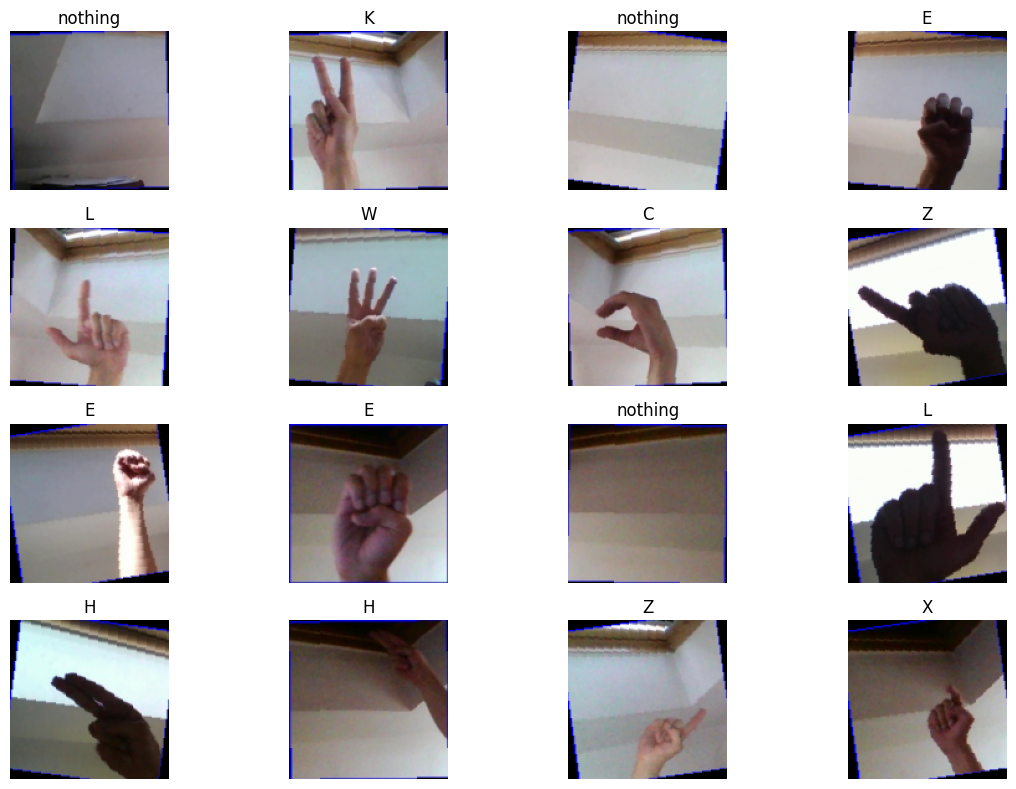

In [13]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(12, 8))
for i in range(min(16, len(images))):
    plt.subplot(4, 4, i + 1)
    img = images[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Define the CNN model

A simple convolutional neural network with three conv-pool blocks, dropout for regularisation, and a fully connected classifier head mapping to 29 classes.

In [14]:
class ASLClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = ASLClassifier(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model has {total_params:,} parameters")

Model has 4,591,389 parameters


## 6. Training loop

Train for 15 epochs. Tracks training loss, validation loss, and validation accuracy. The learning rate is halved every 5 epochs.

In [ ]:
train_losses, val_losses, val_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"  Train"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    scheduler.step()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"  Val"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(f"Epoch {epoch:2d}/{EPOCHS}  |  Train Loss: {epoch_train_loss:.4f}  |  Val Loss: {epoch_val_loss:.4f}  |  Val Acc: {epoch_val_acc:.4f}")

## 7. Plot training curves

Visualise loss and accuracy across epochs to check for overfitting or convergence issues.

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")

plt.tight_layout()
plt.show()

## 8. Evaluate on test set

Run the trained model on the held-out test images (one per class) to get a final accuracy reading.

In [ ]:
model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Test Accuracy: {correct}/{total} = {correct / total:.4f}")

## 9. Per-class test predictions

Display each test image alongside the predicted and true label to spot which letters the model confuses.

In [ ]:
test_dataset_no_aug = datasets.ImageFolder(root=str(TEST_DIR), transform=test_transform)
test_imgs = []
for path, _ in test_dataset_no_aug.samples:
    from PIL import Image
    img = Image.open(path).resize((IMG_SIZE, IMG_SIZE))
    test_imgs.append(np.array(img))

plt.figure(figsize=(16, 10))
for i in range(len(class_names)):
    plt.subplot(5, 6, i + 1)
    plt.imshow(test_imgs[i])
    color = "green" if all_preds[i] == all_labels[i] else "red"
    plt.title(f"True: {class_names[all_labels[i]]}\nPred: {class_names[all_preds[i]]}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 10. Save the trained model

Export the model weights so they can be loaded later for inference in the ASL Bridge app.

In [ ]:
MODEL_SAVE_PATH = "letter_classifier.pth"
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")
print(f"Classes: {class_names}")